# Taller 2 Inteligencia artificial
por: Felipe Arcila

Para poder reentrenar el modelo primero es necesario importar la base de datos con la cual haremos en *fine-tuning*. Para este caso, de acuerdo a como se instruyó, se utilizará logistics-sz9jr tomada de https://universe.roboflow.com/large-benchmark-datasets/logistics-sz9jr. El modelo expuesto en el mismo enlace se usará como referencia para analizar las métricas que se alcancen.

In [2]:
!pip install roboflow
from roboflow import Roboflow
import os

rf = Roboflow(api_key="tCbg2aJlWTLt7LSVT10B")
proyecto = rf.workspace("large-benchmark-datasets").project("logistics-sz9jr")
version = proyecto.version(2)
dataset = version.download("yolov8")

# Verificamos la ruta absoluta asignada por Kaggle
ruta_datos = f"{dataset.location}/data.yaml"
print(f"Archivo de configuración guardado en: {ruta_datos}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud


Extracting Dataset Version Zip to Logistics-2 in yolov8:: 100%|██████████| 189460/189460 [00:30<00:00, 6257.10it/s] 


Archivo de configuración guardado en: /kaggle/working/Logistics-2/data.yaml


## Modelo e hiperparámetros
Una vez preparados los datos, se puede importar alguno de los modelos disponibles para el nuevo entrenamiento. En este caso se utilizó YOLOv8s, correspondiente a la versión small, la segunda más pequeña y menos costosa computacionalmente luego de YOLOv8n (nano). Se eligió esta variante sobre las demás porque, al contar con una arquitectura más compleja que la versión mínima, tiende a ofrecer mejor rendimiento sin incurrir en los costos más altos que implican las versiones mayores. Dado que el desarrollo del taller se realizó bajo el plan gratuito de Kaggle, esta elección facilitó cumplir con los requerimientos del trabajo sin sobrepasar el límite mensual de horas de GPU de la plataforma.
Por la misma razón se asignaron únicamente 30 épocas al entrenamiento, asumiendo el riesgo de que un proceso más extenso pudiera mejorar el comportamiento del modelo. La paciencia se fijó en 8 épocas con el objetivo de completar las 30 disponibles en la mayoría de los escenarios. En este contexto particular, este parámetro cumple principalmente la función de detener el entrenamiento ante un estancamiento prolongado, más que la de buscar una convergencia temprana.

El parámetro imgsz reescala las imágenes para reducir el costo computacional. Se eligió el valor de 640 tras indagar en el comportamiento del algoritmo de redimensionamiento, el cual toma la dimensión más larga, la iguala al valor del parámetro y rellena con franjas grises las filas o columnas faltantes de la dimensión menor, evitando así distorsiones o recortes. En el foro consultado se recomendaba este tamaño como punto de partida, aunque también se discutía si un valor mayor podría mejorar el rendimiento. Sin embargo, un tamaño de imagen más alto incrementa el costo computacional y de memoria, lo cual no era recomendable dadas las limitaciones antes descritas.
El entrenamiento se configuró con el optimizador AdamW. Se trata de una variante de Adam que incorpora un weight decay desacoplado: en lugar de incluir la penalización como parte del gradiente, aplica la reducción de pesos de forma uniforme sobre todos los parámetros, independientemente de su historial de gradientes. Esto permite que la regularización funcione de manera consistente y que las actualizaciones no sean excesivamente bruscas, lo cual es especialmente relevante al partir de un modelo preentrenado cuyos pesos ya contienen conocimiento útil.
La tasa de aprendizaje inicial se fijó en 0.001, valor estándar en pytorch descrito en la propia documentación de AdamW. A futuro podría considerarse probar otros valores iniciales que puedan mejorar la convergencia, pero la elección se mantuvo tras verificar que no había *overfitting*. Complementariamente, se estableció un período de calentamiento de 1.5 épocas en el que la tasa de aprendizaje sube gradualmente desde cero hasta el valor inicial, estabilizando el entrenamiento en sus primeras iteraciones y protegiendo los pesos preentrenados de actualizaciones prematuras de gran magnitud.

El parámetro *amp* habilita el entrenamiento en precisión mixta, alternando entre representaciones float16 y float32 según el contexto de cada operación, con el objetivo de reducir el consumo de memoria y acelerar los cálculos sin penalizar significativamente la precisión del modelo. El tamaño de batch se fijó en 32, buscando un valor suficientemente grande para producir estimaciones de gradiente estables y reducir el ruido en las actualizaciones, pero sin exceder la memoria disponible en la *GPU*. Finalmente, se utilizó un scheduler con decaimiento en forma de curva cosenoidal, que reduce la tasa de aprendizaje de manera continua y suave a lo largo del entrenamiento. A diferencia de un scheduler escalonado, este enfoque evita caídas abruptas en la tasa, favoreciendo una convergencia más fina una vez que el modelo ya se encuentra en una región prometedora del espacio de parámetros.


In [ ]:
from ultralytics import YOLO

modelo = YOLO("yolov8s.pt")

resultados = modelo.train(
    data=ruta_datos, 
    epochs=30,
    patience=8, 
    imgsz=640,
    batch=32,          
    device=0,          
    amp=True,          
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    warmup_epochs=1.5,
    project="/kaggle/working/runs",
    name="modelo_logistico"
)

In [ ]:
#from ultralytics import YOLO

#modelo = YOLO("yolov8s.pt")

#resultados = modelo.train( data=ruta_datos, epochs=30, patience=8, imgsz=640, batch=32,
#device=0,
#amp=True,
#optimizer="AdamW", lr0=0.001, cos_lr=True, warmup_epochs=1.5, project="/kaggle/working/runs", name="modelo_logistico" )

Entrenado el modelo, se reconstruyó en un archivo de python que será necesario luego para la etapa de *deployment*. Esta parte se hizo en local.

In [2]:
%%writefile api_logistica.py
import io
import litserve as ls
from PIL import Image
from ultralytics import YOLO

class LogisticsAPI(ls.LitAPI):
    def setup(self, device):
        ruta_modelo = r"C:\Users\Fap15\Downloads\best.onnx"
        self.model = YOLO(ruta_modelo, task="detect")

    def decode_request(self, request):
        archivo_imagen = request["image"]
        
        if hasattr(archivo_imagen, "file"):
            bytes_imagen = archivo_imagen.file.read()
        else:
            bytes_imagen = archivo_imagen.read()
            
        imagen = Image.open(io.BytesIO(bytes_imagen)).convert("RGB")
        return imagen

    def predict(self, image):
        predicciones = self.model.predict(image, conf=0.25, imgsz=640, verbose=False)[0]
        detecciones = []
        
        for caja in predicciones.boxes:
            id_clase = int(caja.cls[0].item())
            detecciones.append({
                "class_id": id_clase,
                "class_name": predicciones.names[id_clase],
                "confidence": float(caja.conf[0].item()),
                "xyxy": [float(coordenada) for coordenada in caja.xyxy[0].tolist()]
            })
            
        return detecciones

    def encode_response(self, output):
        return {"detections": output}

if __name__ == "__main__":
    api = LogisticsAPI()
    servidor = ls.LitServer(api, accelerator="auto")
    servidor.run(port=8000)

Writing api_logistica.py


Aquí se puede ver el resultado que arroja la consola al entregarle una imagen de prueba. Como se evidencia, el modelo pudo detectar diferentes objetos como un contenedor, un camión, un montacargas o una placa de vehículo, todos esos presentes en la imagen de prueba que se puede ver más adelante en el informe. Por otro lado, también parece cometer un par de errores de identificación. Por ejemplo, no hay ninguna van en la imagen, pero el modelo indica lo contrario. Esto es una prueba pequeña y no es verdaderamente representativa, pero ilustra el funcionamiento del modelo. Más adelante se reconstruyó la imagen con los marcos y las predicciones para que se vea más clara la ilustración.

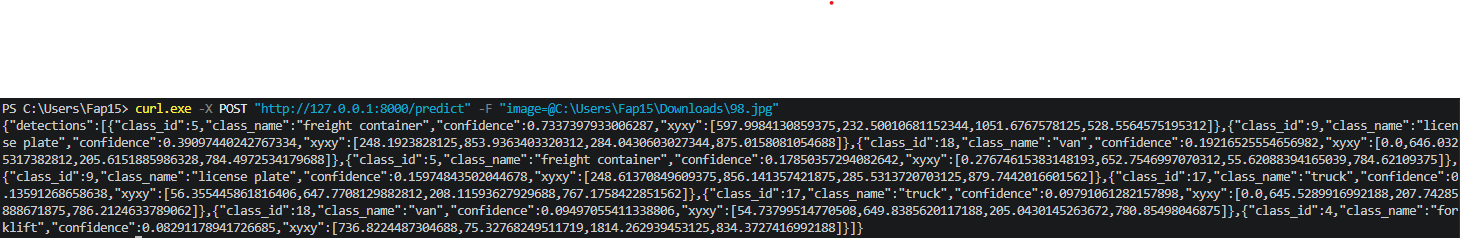



image 1/1 /kaggle/input/datasets/felipear/prueba2/98.jpg: 384x640 1 forklift, 2 freight containers, 1 ladder, 2 license plates, 2 trucks, 2 vans, 270.5ms
Speed: 3.4ms preprocess, 270.5ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
=== Objetos detectados ===
  - freight container: 72.8% de confianza | bbox: [598.1, 232.3, 1051.7, 528.5]
  - license plate: 25.2% de confianza | bbox: [248.5, 853.9, 283.7, 875.2]
  - van: 17.1% de confianza | bbox: [0.0, 645.9, 205.6, 784.8]
  - freight container: 16.0% de confianza | bbox: [0.3, 652.7, 55.5, 784.2]
  - truck: 14.4% de confianza | bbox: [0.1, 646.4, 207.6, 785.9]
  - truck: 14.0% de confianza | bbox: [56.3, 647.9, 207.9, 773.5]
  - license plate: 10.7% de confianza | bbox: [249.1, 856.2, 285.2, 879.8]
  - van: 8.9% de confianza | bbox: [54.5, 649.9, 205.0, 780.6]
  - forklift: 8.0% de confianza | bbox: [734.2, 74.5, 1814.7, 835.1]
  - ladder: 6.5% de confianza | bbox: [829.5, 73.0, 1808.5, 817.6]


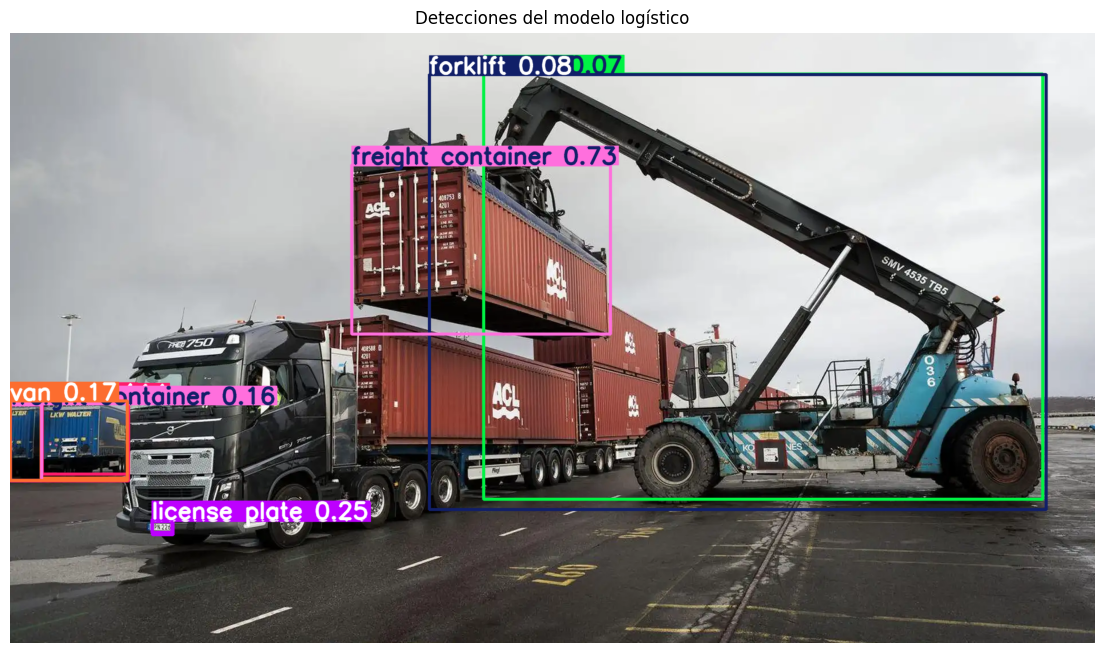

Total de cajas detectadas: 10
5 freight container 0.7282547950744629
9 license plate 0.25155559182167053
18 van 0.1713971197605133
5 freight container 0.1601489633321762
17 truck 0.14403145015239716
17 truck 0.13978694379329681
9 license plate 0.10664588212966919
18 van 0.08919398486614227
4 forklift 0.08030147105455399
8 ladder 0.06530232727527618


In [6]:
!pip install ultralytics
import shutil
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Cargar el modelo (copia al directorio de trabajo si viene de /input)
ruta_pesos = "/kaggle/input/models/felipear/yolofelipe/onnx/default/1/best.pt"
ruta_trabajo = "/kaggle/working/best.pt"
shutil.copy(ruta_pesos, ruta_trabajo)

modelo = YOLO(ruta_trabajo)

# 2. Ruta de la imagen a predecir
ruta_imagen = "/kaggle/input/datasets/felipear/prueba2/98.jpg"

# 3. Hacer la predicción
resultados = modelo.predict(
    source=ruta_imagen,
    conf=0.05,       # confianza mínima
    imgsz=640,
    save=False,       # guarda la imagen con las cajas dibujadas
    project="/kaggle/working/predicciones",
    name="resultado"
)

# 4. Mostrar los objetos detectados
print("=== Objetos detectados ===")
for r in resultados:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        nombre_clase = r.names[cls_id]
        confianza = float(box.conf[0])
        coordenadas = [round(x, 1) for x in box.xyxy[0].tolist()]
        print(f"  - {nombre_clase}: {confianza:.1%} de confianza | bbox: {coordenadas}")

# 5. Visualizar la imagen con las detecciones
img_resultado = resultados[0].plot(conf=0.05)  # imagen con cajas dibujadas
plt.figure(figsize=(14, 8))
plt.imshow(img_resultado[:, :, ::-1])  # BGR → RGB
plt.axis("off")
plt.title("Detecciones del modelo logístico")
plt.show()
print(f"Total de cajas detectadas: {len(resultados[0].boxes)}")
for box in resultados[0].boxes:
    print(int(box.cls[0]), resultados[0].names[int(box.cls[0])], float(box.conf[0]))

Con la reconstrucción es posible profundizar el análisis anterior. Se hace evidente, por ejemplo, que el modelo logró identificar un contenedor rojo pero ignoró los demás, que a primera vista parecen muy similares. De igual manera, detectó uno adicional al fondo de la imagen, aunque con confusión entre las clases freight container y van, confusión que puede explicarse precisamente por la pérdida de resolución asociada a la distancia y al reescalado. Aumentar el parámetro imgsz podría mejorar esta predicción en casos similares.

En la misma línea, un entrenamiento más extenso y el uso de versiones más grandes del modelo deberían traducirse en mejoras adicionales de rendimiento. El *fine-tuning* realizado no fue el más exhaustivo, condicionado por las limitaciones técnicas del entorno de desarrollo. Aun así, el modelo logró identificar correctamente una cantidad considerable de objetos en una imagen seleccionada deliberadamente por su alta saturación de elementos, con el propósito de llevar el modelo cerca de su límite. Como resultado destacable, predijo con un nivel de confianza relativamente alto objetos pequeños como la placa del camión, lo cual resulta inesperado considerando que precisamente este tipo de objetos debería verse más perjudicado por el reescalado de la imagen.

El modelo pudo predecir también la presencia de camiones pero no logró señalar el camión en el centro de la imagen, sino que confundió otros elementos con camiones. De nuevo esto muestra las limitaciones del modelo construido.

También se puede utilizar el modelo mediante la cámara en tiempo real. Un algoritmo de python para hacerlo es el siguiente. Esto también se ejecutó en local.

In [ ]:
%%writefile prueba_camara.py
import io
import argparse
from typing import List, Dict, Any

import litserve as ls
from fastapi import UploadFile
import cv2
from PIL import Image
from ultralytics import YOLO

MODEL_PATH = r"C:\Users\Fap15\Downloads\best.onnx"

class LogisticsAPI(ls.LitAPI):
    def setup(self, device: str):
        self.model = YOLO(MODEL_PATH, task="detect")

    def decode_request(self, request: Dict[str, Any]):
        if isinstance(request, dict) and "image" in request:
            f: UploadFile = request["image"]
            image = Image.open(io.BytesIO(f.file.read())).convert("RGB")
            return image
        raise ValueError("Expected form-data with 'image'")

    def predict(self, image: Image.Image) -> List[Dict[str, Any]]:
        results = self.model.predict(image, conf=0.25, imgsz=640, verbose=False)[0]
        dets = []
        for b in results.boxes:
            cls_id = int(b.cls[0].item())
            dets.append({
                "class_id": cls_id,
                "class_name": results.names[cls_id],
                "confidence": float(b.conf[0].item()),
                "xyxy": [float(x) for x in b.xyxy[0].tolist()],
            })
        return dets

    def encode_response(self, output: List[Dict[str, Any]]):
        return {"detections": output}


def run_realtime_camera(model_path: str, camera_index: int = 0, conf: float = 0.25, imgsz: int = 640) -> None:
    model = YOLO(model_path, task="detect")
    cap = cv2.VideoCapture(camera_index)

    if not cap.isOpened():
        raise RuntimeError(f"No se pudo abrir la camara con indice {camera_index}")

    print("Camara encendida. Presiona 'q' para salir.")

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                print("No se pudo leer frame de la camara.")
                break

            results = model.predict(frame, conf=conf, imgsz=imgsz, verbose=False)[0]
            annotated = results.plot()
            cv2.imshow("Deteccion en tiempo real", annotated)

            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="API y deteccion en tiempo real para logistica")
    parser.add_argument("--mode", choices=["api", "camera"], default="camera")
    parser.add_argument("--port", type=int, default=8000)
    parser.add_argument("--camera-index", type=int, default=0)
    parser.add_argument("--conf", type=float, default=0.25)
    parser.add_argument("--imgsz", type=int, default=640)
    parser.add_argument("--model-path", type=str, default=MODEL_PATH)
    args = parser.parse_args()

    if args.mode == "api":
        server = ls.LitServer(LogisticsAPI(), accelerator="auto")
        server.run(port=args.port)
    else:
        run_realtime_camera(
            model_path=args.model_path,
            camera_index=args.camera_index,
            conf=args.conf,
            imgsz=args.imgsz,
        )


A continuación una imagen de lo que mostraba la pantalla y la predicción acertada que hizo de la categoría persona.

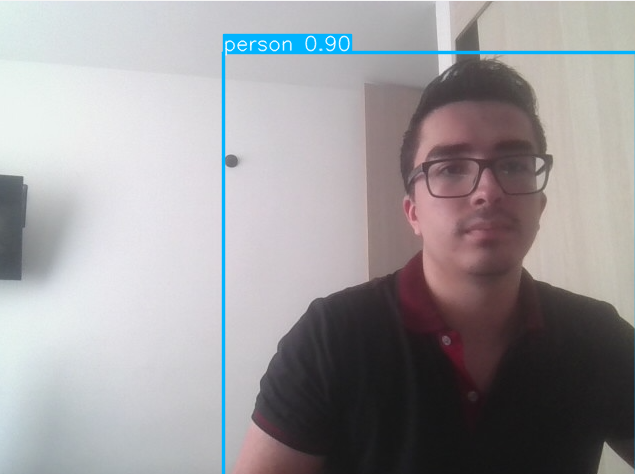

## Métricas de validación
Para un análisis más justo y completo del modelo se requieren métricas. Primero se evaluará el comportamiento sobre el conjunto de validación, para verificar si los resultados son prometedores, y luego se compararán con los del conjunto de prueba o *test*: si las métricas son similares entre ambos conjuntos, esto indica que el modelo generaliza bien a imágenes nuevas y que los resultados son confiables.

Las métricas evaluadas fueron la precisión, denotada con la letra *P*, que representa el porcentaje de detecciones a las que se les asignó la etiqueta correcta, y el recall, denotado con *R*, que representa el porcentaje de objetos presentes en la imagen que el modelo logró detectar. La métrica *mAP@50* promedia la precisión de cada clase exigiendo que el marco predicho se solape al menos un 50% con el dibujado manualmente al etiquetar los datos, según el criterio IoU. Se busca un valor alto, que indique que el modelo está localizando correctamente los objetos. Su contraparte *mAP@50-95* sigue la misma lógica pero repite el cálculo con saltos del 5% entre el 50% y el 95%, y promedia los resultados obtenidos en cada umbral. A medida que el umbral aumenta, el algoritmo exige un solapamiento mayor para considerar una detección como exitosa, lo que la convierte en una métrica más exigente. Finalmente, el *F1 score* agrupa *P* y *R* en una sola métrica. Esto ocurre porque un modelo que detecta pocos o ningún objeto (bajo *R*) puede lograr fácilmente una *P* alta sin tener realmente buen desempeño (un modelo que no detecta nada no comete errores de clasificación). De manera similar, un modelo que clasifica muy bien pero no detecta casi nada tampoco es útil en este contexto (de nada sirve que etiquete bien un par de objetos si termina ignorando todo lo demás). Esta métrica aprovecha el intervalo [0,1] de esas métricas para que la fórmula $F_1 = \frac{2}{\frac{1}{\text{recall}} + \frac{1}{\text{precision}}} = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$ tenga sentido y se mantenga en el mismo rango. En todos los estadísticos descritos se busca un valor lo más cercano a 1 posible.

Por último, se utilizó una matriz de confusión para analizar los errores del modelo con mayor detalle. Esta matriz muestra cuántas veces cada tipo de objeto fue identificado con cada una de las etiquetas posibles, lo que permite observar en qué pares de categorías el modelo tiende a confundirse. La etiqueta *background* representa las ocasiones en que el modelo no detectó ningún objeto en una región donde sí había uno, es decir, un falso negativo. Este análisis resulta útil tanto para evaluar el desempeño real del modelo como para identificar qué tipos de datos convendría incorporar en un eventual *fine-tuning*, con el fin de que el modelo aprenda a distinguir mejor entre las categorías con mayor nivel de confusión.

El motivo por el cual se eligieron las métricas descritas anteriormente es que se complementan de manera adecuada y permiten evaluar distintos aspectos relevantes del desempeño del modelo. Con ellas es posible determinar cuántas veces la detección se realiza correctamente, cuántas veces la etiqueta asignada corresponde al objeto real, qué tan precisos son los marcos generados por el modelo y, además, identificar las causas de los errores. Estas métricas permiten distinguir si un fallo proviene de un falso negativo, de la confusión esporádica con otra categoría o de la posible tendencia del modelo a confundir ciertos pares de clases entre sí. En conjunto, ofrecen una visión integral que facilita tanto la evaluación del rendimiento como la identificación de áreas específicas en las que el modelo requiere mejoras.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.6 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,133,324 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 932.1±408.3 MB/s, size: 48.0 KB)
val: Scanning /kaggle/working/Logistics-2/valid/labels... 18988 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18988/18988 1.0Kit/s 18.3s<0.0s
val: /kaggle/working/Logistics-2/valid/images/-Docker-1-Do_jpg.rf.5c00af35cf477fec60189674679ea214.jpg: 2 duplicate labels removed
val: New cache created: /kaggle/working/Logistics-2/valid/labels.cache
        

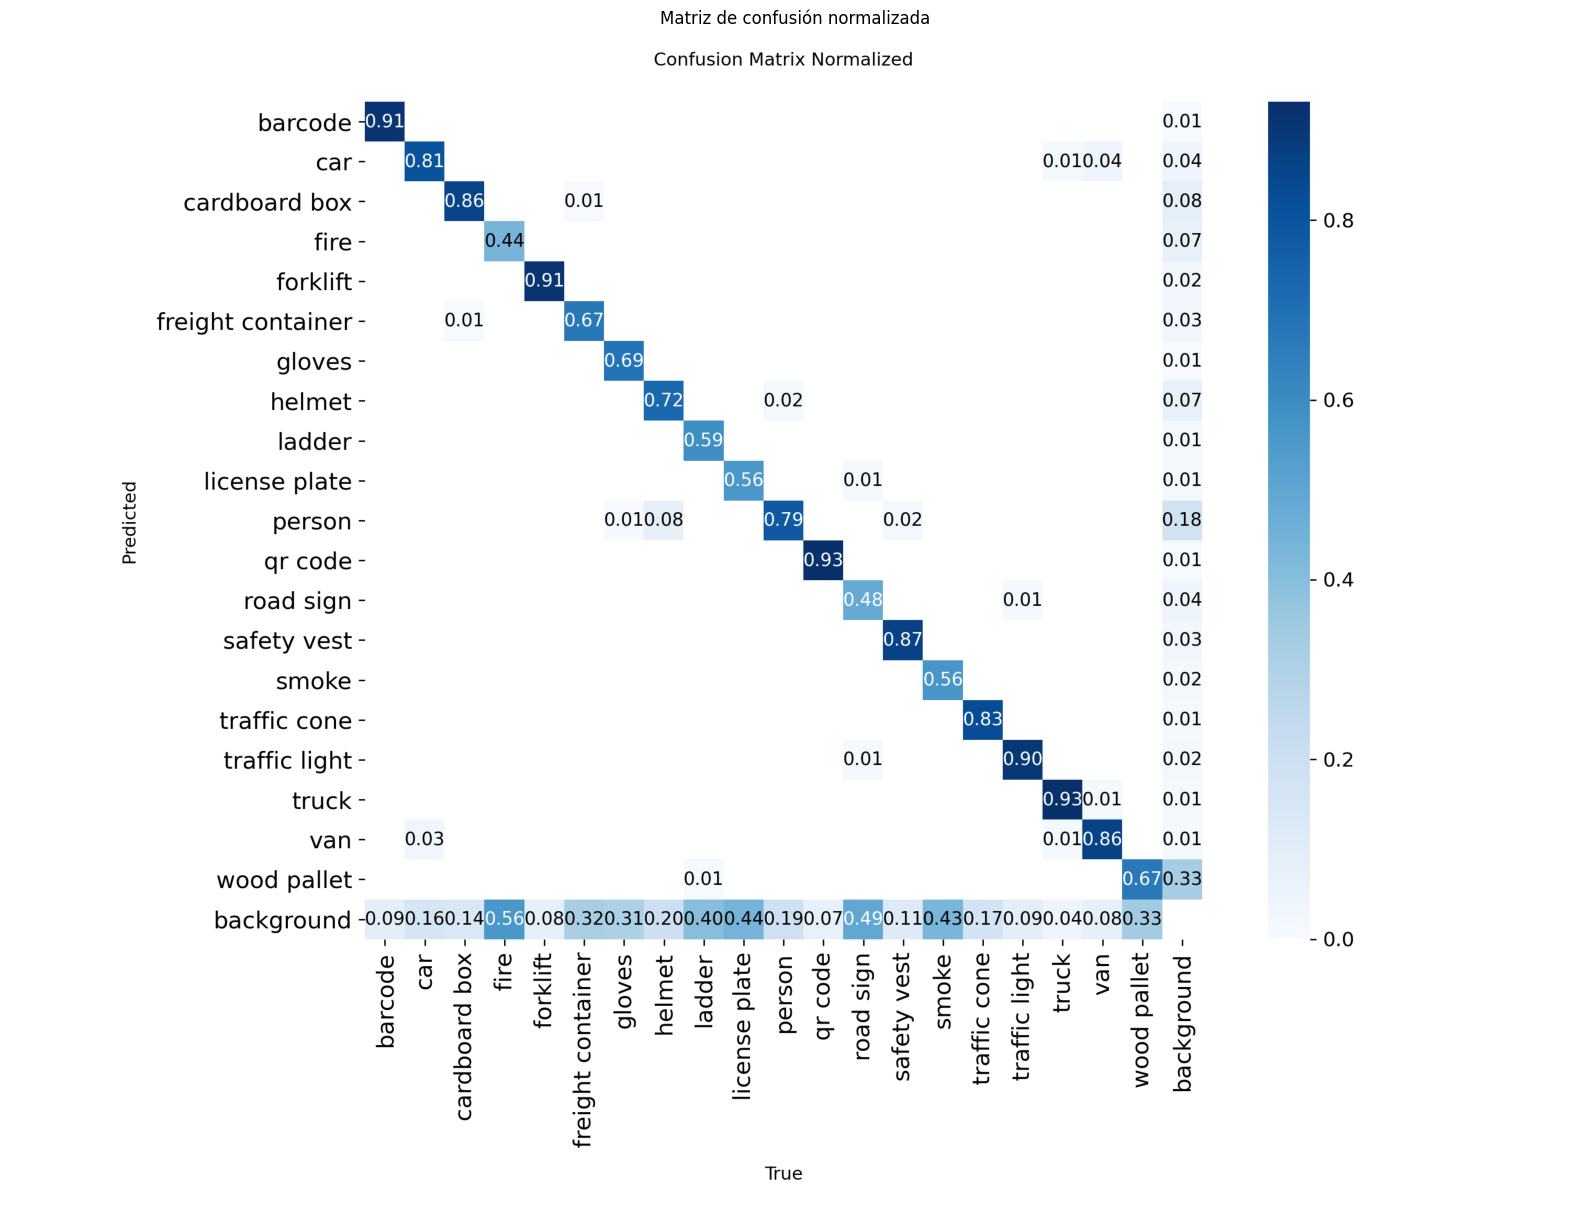

Matriz encontrada en: /kaggle/working/plots_confusion/confusion_matrix_normalized.png


In [4]:
!pip install ultralytics
import shutil
import glob
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# Carga del modelo
ruta_pesos = "/kaggle/input/models/felipear/yolofelipe/onnx/default/1/best.pt"
ruta_trabajo = "/kaggle/working/best.pt"
shutil.copy(ruta_pesos, ruta_trabajo)
modelo = YOLO(ruta_trabajo)

# Validación forzando plots en una ruta fija
SAVE_DIR = "/kaggle/working/plots_confusion"

metricas_validacion = modelo.val(
    plots=True,
    save_dir=SAVE_DIR
)

# Búsqueda y visualización de la matriz
rutas = glob.glob(f"{SAVE_DIR}/**/confusion_matrix_normalized.png", recursive=True)
if not rutas:
    rutas = glob.glob(f"{SAVE_DIR}/**/confusion_matrix.png", recursive=True)

if rutas:
    img = Image.open(rutas[0])
    plt.figure(figsize=(16, 14))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Matriz de confusión normalizada")
    plt.tight_layout()
    plt.show()
    print(f"Matriz encontrada en: {rutas[0]}")
else:
    print("No se generó la matriz. Archivos disponibles en el directorio:")
    for f in glob.glob(f"{SAVE_DIR}/**/*", recursive=True):
        print(" ", f)

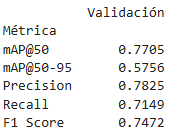

tomado de un bloque de código en la parte final del archivo.

Partiendo por la precisión, en general los resultados fueron relativamente altos para la mayoría de categorías, superando en todos los casos el umbral de 0.5. Esto significa que más de la mitad de las veces que un objeto recibió una etiqueta, esta correspondía efectivamente al objeto asignado. Las categorías con menor precisión fueron *road sign* con 0.51 y *freight container* con 0.512, mientras que las más altas fueron *smoke* con 0.891, *traffic light* con 0.89 y *truck* con 0.88. La gran mayoría de categorías se ubican por encima del umbral de 0.7, y la métrica promedio sobre el conjunto de validación fue de 0.7825, un resultado aceptable considerando las limitaciones técnicas bajo las cuales se trabajó y cercano al del modelo público disponible junto a la base de datos en el portal de *Roboflow*.

En cuanto al *recall*, destacan las categorías *fire* con 0.349 y *road sign* con 0.382 por presentar valores mucho más bajos que el resto. En otras palabras, por cada 10 incendios o señales de tránsito el modelo ignora más de 6. Este comportamiento es especialmente problemático en *road sign*, que además muestra baja precisión. Por el contrario, las categorías con valores de *recall* más altos fueron *qr code* con 0.925 y *truck* con 0.923, muy cercanos a 1, lo que indica que el modelo detecta con relativa facilidad la presencia de un objeto cuando estos están presentes. El promedio fue de 0.7149, superior al 0.707 reportado por el modelo de referencia de *Roboflow*.

El F1 promedio fue de 0.7472, un resultado sólido dadas las limitaciones técnicas, aunque en este caso no se cuenta con un valor de referencia del modelo de *Roboflow* para comparar.

Respecto al *mAP@50*, el valor más bajo lo obtuvo, de forma nada sorpresiva, la categoría road sign con 0.433, que ya se había identificado con P y R bastante bajos. *Fire* también recibió una métrica baja en esta categoría, a pesar de tener una precisión relativamente alta. Esto tiene sentido al considerar el concepto de solapamiento y su relación con la detección inicial. Aun así, la métrica promedio fue de 0.7705, superior a la del modelo de referencia, que obtuvo 0.766. La variante *mAP@50-9*5 genera caídas significativas en la mayoría de valores, lo que indica que el modelo necesita mejorar los marcos que asigna a los objetos para que coincidan mejor con los marcos predibujados en el conjunto de datos. Esto es esperable considerando que se usó una versión relativamente básica de *Yolo* y que el *fine-tuning* se realizó con bastantes limitaciones. Sin embargo, el modelo de referencia no reporta este estadístico, por lo que no es posible realizar una comparación más profunda.

Finalmente, respecto a la matriz de confusión, es evidente que la mayoría de errores se dieron por asumir la presencia de un objeto donde no lo había, especialmente común en la categoría *person*, donde el 18% de las etiquetas fueron falsos positivos, o bien por ignorar un objeto al confundirlo con el fondo. Esto ocurre con frecuencia en *road sign* y *license plate*, probablemente por tratarse de objetos pequeños y usualmente lejanos a la cámara, lo que los hace más susceptibles al reescalado de la imagen. También en *fire* y *smoke*, posiblemente debido a sus formas abstractas y poco definidas, que dificultan el aprendizaje de patrones precisos. Aunque no se observa demasiada confusión entre categorías, la más común es etiquetar un casco como persona, con una métrica del 8%, un valor relativamente alto que sugiere la conveniencia de realizar otro *fine-tuning* para mejorar la diferenciación entre ambas clases.




## Evaluación sobre el conjunto *test* 
Finalmente solo quedaría comparar las principales métricas entre los conjuntos de test y validación para verificar si son similares, lo que indica una adecuada generalización, verificando la confiabilidad de las métricas en el conjunto de validación antes analizadas.

In [3]:
metricas_test = modelo.val(split="test")
print(f"Test mAP@50:    {metricas_test.box.map50:.4f}")
print(f"Test mAP@50-95: {metricas_test.box.map:.4f}")
print(f"Test Precision: {metricas_test.box.mp:.4f}")
print(f"Test Recall:    {metricas_test.box.mr:.4f}")
nombres_clases = metricas_test.names
ap_test = metricas_test.box.ap50

print("AP@50 por clase (TEST):")
for i, nombre in enumerate(nombres_clases.values()):
    print(f"  {nombre:20s}: {ap_test[i]:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.8±3.2 MB/s, size: 45.0 KB)
val: Scanning /kaggle/working/Logistics-2/test/labels... 9525 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9525/9525 763.0it/s 12.5s<0.0s
val: New cache created: /kaggle/working/Logistics-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 596/596 5.6s/it 56:05<5.6ss
                   all       9525      36721      0.774       0.72       0.77      0.576
               barcode        272        283      0.839      0.929      0.885      0.653
                   car       1000       1379      0.792      0.781      0.856      0.705
         cardboard box        443       4995      0.876       0.82       0.89      0.767
                  fire       1133       2793      0.691      0.344      0.471      0.237
              forklift        949       1103      0.

In [4]:
p = metricas_test.box.mp
r = metricas_test.box.mr
f1 = 2 * (p * r) / (p + r)
print(f"F1 Score (test): {f1:.4f}")

F1 Score (test): 0.7456


In [8]:
import pandas as pd

data = {
    "Métrica": ["mAP@50", "mAP@50-95", "Precision", "Recall", "F1 Score"],
    "Validación": [
        metricas_validacion.box.map50,
        metricas_validacion.box.map,
        metricas_validacion.box.mp,
        metricas_validacion.box.mr,
        f1_val
    ],
    "Test": [
        metricas_test.box.map50,
        metricas_test.box.map,
        metricas_test.box.mp,
        metricas_test.box.mr,
        0.7456
    ]
}

df = pd.DataFrame(data).set_index("Métrica")
df = df.round(4)
print(df.to_string())

           Validación    Test
Métrica                      
mAP@50         0.7705  0.7698
mAP@50-95      0.5756  0.5762
Precision      0.7825  0.7736
Recall         0.7149  0.7195
F1 Score       0.7472  0.7456


Como se puede ver, las métricas son prácticamente iguales, e incluso algunas de prueba resultan ligeramente superiores. Esto es precisamente lo que se buscaba, ya que indica que, para nuevos conjuntos de imágenes en condiciones similares (misma resolución y claridad en la presencia del objeto), el comportamiento del modelo debería ser consistente con lo observado hasta ahora. En consecuencia, el análisis de su desempeño realizado a partir de las métricas calculadas es válido y puede extrapolarse con confianza.


## Conclusión
En síntesis, *YOLO* es, en sus distintas versiones, un modelo muy funcional para la detección de objetos en imágenes. Incluso con una de sus variantes más simples y de menor número de parámetros es posible construir modelos con métricas sólidas, siempre que se cuente con un dataset de calidad que permita aprovechar el potencial del *transfer learning* y el *fine-tuning*. Si bien el modelo resultante mostró limitaciones concretas en el ejemplo evaluado, su comportamiento general permitió ilustrar de forma visual e intuitiva las capacidades de este tipo de arquitecturas.

De querer mejorar el desempeño alcanzado, se recomienda en primer lugar un entrenamiento más extenso que permita una mejor convergencia, explorar valores más altos de resolución para verificar si efectivamente se traduce en mejoras para objetos pequeños como placas de automóvil, y, de superarse las limitaciones técnicas bajo las cuales se trabajó, considerar una versión más grande de *YOLO* como modelo base.

# Referencias
- Ultralytics. (2026, January 20). Explore Ultralytics YOLOV8. Documentación De Ultralytics YOLO. https://docs.ultralytics.com/es/models/yolov8/
- Logistics object detection model by large benchmark datasets. (2025, January 31). Roboflow. https://universe.roboflow.com/large-benchmark-datasets/logistics-sz9jr
- Ultralytics. (2026, January 14). Performance Metrics Deep Dive. Ultralytics YOLO Docs. https://docs.ultralytics.com/guides/yolo-performance-metrics/
- Jocher, G. (2024, March 31). Re: What is Box P R mAP50 mAP50-95? [Online forum comment]. GitHub. https://github.com/ultralytics/ultralytics/issues/9446
- Luque, J. C. (2016, April 13). El hombre más fuerte del mundo se sube al Volvo FH16 para arrastrar 750 toneladas. Car And Driver. https://www.caranddriver.com/es/coches/planeta-motor/a10185/el-hombre-mas-fuerte-del-mundo-se-sube-al-volvo-fh16-para-arrastrar-750-ton/
- A1exan10er. (2023, May 11). True Meaning of Argument “imgsz”? [Online forum post]. GitHub. https://github.com/ultralytics/ultralytics/issues/2546
- Anthropic. (2025). Claude (claude-sonnet-4-6) [Asistente de IA para programación y comprensión]. https://www.claude.ai
- Microsoft. (2026). Copilot [Asistente de IA para redacción]. Microsoft. https://copilot.microsoft.com

